# TabNet Optimization — Steps 1 & 2

**Goal:** Close the R² gap between TabNet (0.176) and KNN (0.971) identified in the short paper.

**Diagnosis:** TabNet's MAE ($2,168) is reasonable but RMSE ($49,200) is catastrophic. A handful of high-value outliers dominate squared error.

**This notebook implements:**
- **Step 1:** Match KNN's preprocessing pipeline; target-encoded `make`/`model`, one-hot `fuel_type`/`transmission`, z-scored numerics (vs. the original label-encoded 3-feature run).
- **Step 2:** Address high-value outliers via (a) 1st/99th percentile price clipping and (b) log-target transform so squared errors stop blowing up on the luxury tail.

Hyperparameters are held at the short-paper settings (max_epochs=40, patience=15, batch_size=128) so any improvement is attributable to preprocessing/target changes, not tuning.

In [1]:
# pip install pytorch_tabnet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 2a — Load, drop UCI, clean nulls, clip price outliers

Matches `build_models.py` so the data entering the model is identical to what KNN saw.

In [ ]:
# Pulling data
df = pd.read_csv('../data/merged_output.csv')
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Drop UCI rows (missing year/mileage/model) — source column may be 'uci' or 'UCI'
df = df[~df['source'].str.lower().eq('uci')].copy()
df = df.drop(columns=['source'])
print(f"After dropping UCI: {df.shape[0]:,} rows")

# Drop rows with null target or null categoricals
df = df.dropna(subset=['price', 'make', 'fuel_type', 'transmission', 'model'])

# Impute numeric nulls with median
# Median is more robust to outliers than mean, and we will clip price outliers later
for col in ['year', 'engine_size', 'mileage']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
print(f"After null handling: {df.shape[0]:,} rows")

# STEP 2 (a): Clip price outliers at 1st/99th percentiles
p01 = df['price'].quantile(0.01)
p99 = df['price'].quantile(0.99)
n_clipped = ((df['price'] < p01) | (df['price'] > p99)).sum()
df['price'] = df['price'].clip(p01, p99)
print(f"Price clipped to [${p01:,.0f}, ${p99:,.0f}] — {n_clipped:,} rows affected")
print(f"Cleaned dataset: {df.shape[0]:,} rows")

## Step 1 — Match KNN preprocessing (TargetEncoder + OneHot + StandardScaler)

70/15/15 train/val/test split, encoding fit on training data only.

In [ ]:
high_card_cats = ['make', 'model']
low_card_cats  = ['fuel_type', 'transmission']
numerics       = ['year', 'engine_size', 'mileage']

X = df[high_card_cats + low_card_cats + numerics]
y = df['price']

# Standard 70/15/15 train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Applies target encoding to high-cardinality categoricals, 
# one-hot encoding to low-cardinality categoricals, 
# and standard scaling to numerics
# The columns above are passed as lists
# Note: StandardScaler not strictly necessary for tree-based models, 
# but can help with TabNet's feature selection and training stability
preprocessor = ColumnTransformer(transformers=[
    ('target_enc', TargetEncoder(smooth='auto'), high_card_cats),
    ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist',
                             sparse_output=False, drop='if_binary'), low_card_cats),
    ('num', StandardScaler(), numerics),
], remainder='drop')


preprocessor.fit(X_train, y_train)

# Transform features after fitting to prevent data leakage
X_train_t = preprocessor.transform(X_train).astype(np.float32)
X_val_t   = preprocessor.transform(X_val).astype(np.float32)
X_test_t  = preprocessor.transform(X_test).astype(np.float32)
print(f"Transformed feature count: {X_train_t.shape[1]}")


Train: 193,638 | Val: 41,494 | Test: 41,495
Transformed feature count: 21


## Step 2b — Log-transform the target

`log1p` compresses the luxury tail so squared errors on high-price cars no longer dominate RMSE. Predictions are inverted with `expm1` before computing metrics in dollars.

In [16]:
# TabNet expects 2D float targets
y_train_log = np.log1p(y_train.values).reshape(-1, 1).astype(np.float32)
y_val_log   = np.log1p(y_val.values).reshape(-1, 1).astype(np.float32)

# Keep original dollar-scale targets for evaluation
y_val_raw  = y_val.values
y_test_raw = y_test.values

print(f"Raw price range:    ${y_train.min():,.0f} - ${y_train.max():,.0f}")
print(f"log1p(price) range: {y_train_log.min():.3f} - {y_train_log.max():.3f}")

Raw price range:    $699 - $89,990
log1p(price) range: 6.551 - 11.407


## Train TabNet on log-target

Hyperparameters match the short-paper run (`max_epochs=40`, `patience=15`, `batch_size=128`) so any improvement is attributable to Steps 1 & 2, not tuning.

In [5]:
model = TabNetRegressor(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    seed=RANDOM_STATE,
)

model.fit(
    X_train_t, y_train_log,
    eval_set=[(X_val_t, y_val_log)],
    eval_metric=['mae'],
    max_epochs=40,
    patience=15,
    batch_size=128,
)

/opt/anaconda3/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.46567 | val_0_mae: 0.44896 |  0:00:13s
epoch 1  | loss: 0.1365  | val_0_mae: 0.22989 |  0:00:25s
epoch 2  | loss: 0.12293 | val_0_mae: 0.22074 |  0:00:38s
epoch 3  | loss: 0.10513 | val_0_mae: 0.23478 |  0:00:51s
epoch 4  | loss: 0.10092 | val_0_mae: 0.29363 |  0:01:04s
epoch 5  | loss: 0.09651 | val_0_mae: 0.19587 |  0:01:17s
epoch 6  | loss: 0.0962  | val_0_mae: 0.22863 |  0:01:29s
epoch 7  | loss: 0.08809 | val_0_mae: 0.18725 |  0:01:43s
epoch 8  | loss: 0.08319 | val_0_mae: 0.19652 |  0:01:56s
epoch 9  | loss: 0.08187 | val_0_mae: 0.31644 |  0:02:09s
epoch 10 | loss: 0.08091 | val_0_mae: 0.25621 |  0:02:22s
epoch 11 | loss: 0.07629 | val_0_mae: 0.2463  |  0:02:35s
epoch 12 | loss: 0.07871 | val_0_mae: 0.18771 |  0:02:48s
epoch 13 | loss: 0.07892 | val_0_mae: 0.23024 |  0:03:01s
epoch 14 | loss: 0.07593 | val_0_mae: 0.19037 |  0:03:14s
epoch 15 | loss: 0.07493 | val_0_mae: 0.19172 |  0:03:27s
epoch 16 | loss: 0.07326 | val_0_mae: 0.19419 |  0:03:40s
epoch 17 | los

/opt/anaconda3/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


## Evaluate on held-out test set

Predictions are in log-space — invert with `expm1` before computing dollar-scale metrics. Compare directly to the short paper's TabNet row (MAE=$2,168, RMSE=$49,200, R²=0.176) and KNN (MAE=$1,309, RMSE=$2,512, R²=0.971).

In [ ]:
# Predict in log-space, then invert to dollars
preds_log = model.predict(X_test_t).ravel()
preds = np.expm1(preds_log)

# Regression metrics on original dollar scale
mae  = mean_absolute_error(y_test_raw, preds)
mse  = mean_squared_error(y_test_raw, preds)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_raw, preds)

print("TabNet (Step 1 + Step 2) — Test Set")
print("-" * 42)
print(f"MAE:  ${mae:>10,.0f}")
print(f"RMSE: ${rmse:>10,.0f}")
print(f"R²:    {r2:>10.4f}")
print()
print("Comparison (short paper):")
print(f"  TabNet (orig): MAE=$2,168  RMSE=$49,200  R²=0.176")
print(f"  KNN (k=10):    MAE=$1,309  RMSE=$2,512   R²=0.971")

TabNet (Step 1 + Step 2) — Test Set
------------------------------------------
MAE:  $     1,921
RMSE: $     3,501
R²:        0.9430

Comparison (short paper):
  TabNet (orig): MAE=$2,168  RMSE=$49,200  R²=0.176
  KNN (k=10):    MAE=$1,309  RMSE=$2,512   R²=0.971


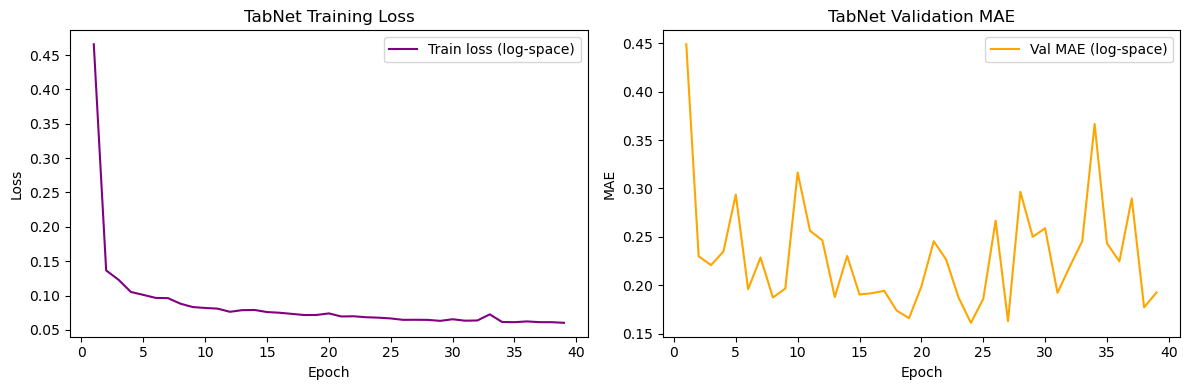

In [14]:
# Training dynamics — confirm log-target stabilizes training
history = model.history
epochs = range(1, len(history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['loss'], 'purple', label='Train loss (log-space)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('TabNet Training Loss'); ax1.legend()

ax2.plot(epochs, history['val_0_mae'], 'orange', label='Val MAE (log-space)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE'); ax2.set_title('TabNet Validation MAE'); ax2.legend()

plt.tight_layout()
plt.show()


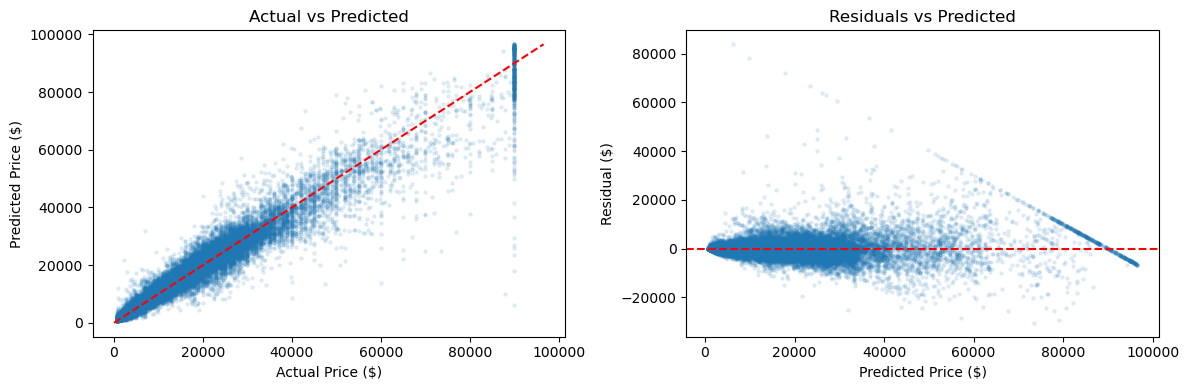

Residual mean=$-141, std=$3,498, max|resid|=$83,788


In [12]:
# Residual diagnostics — confirm the high-value outlier problem is gone
residuals = y_test_raw - preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test_raw, preds, alpha=0.1, s=5)
lim = max(y_test_raw.max(), preds.max())
axes[0].plot([0, lim], [0, lim], 'r--')
axes[0].set(
      xlabel='Actual Price ($)',
      ylabel='Predicted Price ($)',
      title='Actual vs Predicted'
)

axes[1].scatter(preds, residuals, alpha=0.1, s=5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set(
      xlabel='Predicted Price ($)',
      ylabel='Residual ($)',
      title='Residuals vs Predicted'
)

plt.tight_layout()
plt.show()

print(f"Residual mean=${residuals.mean():,.0f}, std=${residuals.std():,.0f}, "
        f"max|resid|=${np.abs(residuals).max():,.0f}")